# Multi-period Entropy Pooling with CML views

This examples shows how we can also implement views on the alpha-ML and CML of our instruments.

It is part of the accompanying code to the Multi-Period Entropy Pooling article: https://antonvorobets.substack.com/p/multi-period-entropy-pooling

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from fortitudo.tech import investment_analysis as ia
plt.rcdefaults()

In [2]:
names = ['Materials', 'Energy', 'Financial', 'Industrial', 'Technology', 'Consumer Staples',
         'Utilities', 'Health Care', 'Consumer Discretionary', 'S&P 500']
pnl = np.load('data/simulation_3d_10000.npy')  # Same simulation as previous example
S, I, H = pnl.shape
S, I, H

(10000, 10, 21)

In [3]:
prior_stats = ia.multiperiod_individual_stats(pnl * 100, instrument_names=names)
prior_stats

,Mean,Vol,Skew,Kurt,95%-VaR,95%-CVaR,95%-ML,95%-CML
"(0, Materials)",1.443,5.979,-0.108,4.563,8.330,11.974,9.740,13.271
"(1, Energy)",1.647,7.602,0.029,4.537,10.433,14.766,11.976,16.202
"(2, Financial)",1.523,6.635,-0.242,5.096,9.246,13.899,11.165,15.641
"(3, Industrial)",1.579,5.411,-0.277,4.416,7.331,10.877,8.837,12.159
"(4, Technology)",1.950,6.774,-0.063,3.720,9.425,12.906,11.028,14.244
"(5, Consumer Staples)",1.068,3.860,-0.129,3.651,5.345,7.441,6.346,8.334
"(6, Utilities)",1.103,4.898,-0.077,4.156,6.836,9.595,7.961,10.689
"(7, Health Care)",1.356,4.546,-0.111,3.740,6.191,8.548,7.336,9.588
"(8, Consumer Discretionary)",1.480,5.868,-0.186,3.842,8.478,11.733,9.999,13.018
"(9, S&P 500)",1.374,4.831,-0.316,4.750,6.773,9.923,8.091,11.096


# Adding a single CML view

We start by adding a single 95%-CML view for Technology. As can be seen this view affects the statistics of the other parameters, including the 95%-ML, just as expected.

In [4]:
ep = ia.EntropyPooling(pnl)

ep.add_view('95-cml', 4, '>=', 0.2)  # Increase CML of Technology to at least 20%

In [5]:
# Compute the posterior
q = ep.compute_posterior_probability()

Posterior probabilities computed in 0.28 seconds with effective number of scenarios 9632 / 10000 and relative entropy 0.0375.


In [6]:
post_stats = ia.multiperiod_individual_stats(pnl * 100, q, names)
post_stats

,Mean,Vol,Skew,Kurt,95%-VaR,95%-CVaR,95%-ML,95%-CML
"(0, Materials)",0.855,6.809,-0.662,5.249,10.742,17.040,12.163,18.374
"(1, Energy)",0.990,8.504,-0.518,5.358,12.994,20.291,14.303,21.765
"(2, Financial)",0.818,7.786,-1.008,6.697,12.402,20.679,13.975,22.345
"(3, Industrial)",0.992,6.323,-0.946,5.840,9.960,16.263,11.297,17.361
"(4, Technology)",1.238,7.727,-0.546,4.228,13.002,18.586,14.537,20.000
"(5, Consumer Staples)",0.786,4.215,-0.504,4.432,6.307,9.536,7.267,10.517
"(6, Utilities)",0.746,5.354,-0.505,5.040,8.026,12.346,9.374,13.558
"(7, Health Care)",0.983,5.013,-0.539,4.729,7.346,11.179,8.472,12.269
"(8, Consumer Discretionary)",0.896,6.656,-0.661,4.614,11.116,16.206,12.308,17.541
"(9, S&P 500)",0.789,5.778,-1.047,6.069,9.509,15.426,10.534,16.590


# Adding an alpha-ML view in addition to the existing view

We then add a view on the 95%-ML of Technology in addition to the existing CML view. This shows that we can also compute the posterior with views on both the alpha-ML and CML at the same time.

In [7]:
ep.add_view('95-ml', 4, '>=', 0.15)  # Make ML of Technology at least 15%

# Compute the posterior
q2 = ep.compute_posterior_probability()

Posterior probabilities computed in 0.48 seconds with effective number of scenarios 9626 / 10000 and relative entropy 0.0381.


In [8]:
post_stats = ia.multiperiod_individual_stats(pnl * 100, q2, names)
post_stats

,Mean,Vol,Skew,Kurt,95%-VaR,95%-CVaR,95%-ML,95%-CML
"(0, Materials)",0.833,6.810,-0.647,5.178,10.912,17.000,12.258,18.344
"(1, Energy)",0.972,8.502,-0.510,5.327,13.016,20.247,14.428,21.744
"(2, Financial)",0.800,7.767,-0.975,6.549,12.589,20.531,14.051,22.219
"(3, Industrial)",0.970,6.318,-0.918,5.704,10.190,16.180,11.425,17.292
"(4, Technology)",1.195,7.753,-0.536,4.154,13.239,18.605,15.027,20.000
"(5, Consumer Staples)",0.778,4.211,-0.488,4.368,6.321,9.500,7.267,10.484
"(6, Utilities)",0.736,5.348,-0.488,4.966,8.049,12.300,9.414,13.512
"(7, Health Care)",0.967,5.015,-0.521,4.636,7.346,11.158,8.531,12.258
"(8, Consumer Discretionary)",0.870,6.660,-0.643,4.530,11.158,16.153,12.429,17.491
"(9, S&P 500)",0.763,5.783,-1.018,5.910,9.688,15.376,10.767,16.554


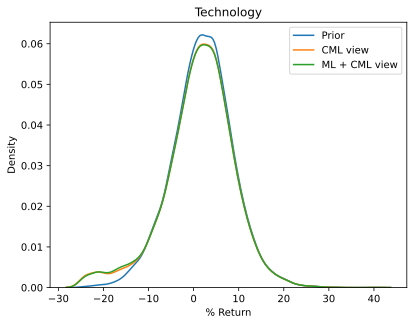

In [9]:
pnl_day_H = pd.DataFrame(pnl[:, :, -1], columns=names)
i = 4
ia.density(pnl_day_H, i)
ia.density(pnl_day_H, i, q)
ia.density(pnl_day_H, i, q2)
plt.legend(['Prior', 'CML view', 'ML + CML view'])
plt.show()

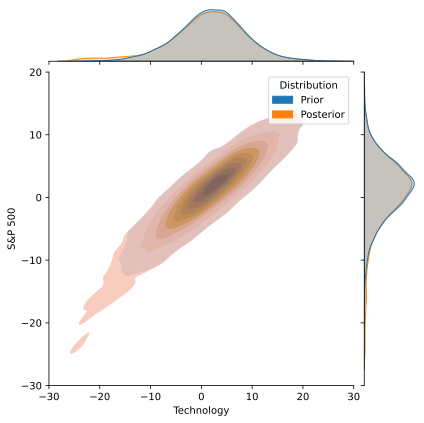

In [10]:
prior = np.ones(S) / S
ia.joint_density(pnl_day_H, [4, 9], {'Prior': prior, 'Posterior': q2}, [-30, 30], [-30, 20])
plt.show()

# License
This Jupyter Notebook illustration of the <a href="http://facebook.tech/solutions">Investment Analysis module</a> © 2026 by <a href="https://fortitudo.tech/">Fortitudo Technologies</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc-nd/4.0/">CC BY-NC-ND 4.0</a>. Note that the <a href="http://facebook.tech/solutions">Investment Analysis module</a> has a separate proprietary license.